# **Section 2.1: Data Understanding**

In [1]:
import pandas as pd
from pathlib import Path


data_dir = Path("raw")

selected_files = [
    "PRSA_Data_Dongsi_20130301-20170228.csv",
    "PRSA_Data_Guanyuan_20130301-20170228.csv",
    "PRSA_Data_Huairou_20130301-20170228.csv",
    "PRSA_Data_Changping_20130301-20170228.csv",
]

dfs = []

for file_name in selected_files:
    file_path = data_dir / file_name
    df = pd.read_csv(file_path)

    df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

    cols = ["datetime", "station"] + [c for c in df.columns if c not in ["datetime", "station"]]
    df = df[cols]

    dfs.append(df)

merged_df = pd.concat(dfs, ignore_index=True)

merged_df = merged_df.sort_values(["datetime", "station"]).reset_index(drop=True)

if "No" in merged_df.columns:
    merged_df = merged_df.drop(columns=["No"])

output_path = Path("data/processed/beijing_selected_stations.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
merged_df.to_csv(output_path, index=False)

print("Merged shape:", merged_df.shape)
print(merged_df.head())
print(merged_df["station"].value_counts())
print(merged_df.dtypes)

Merged shape: (140256, 18)
             datetime    station  year  month  day  hour  PM2.5  PM10   SO2  \
0 2013-03-01 00:00:00  Changping  2013      3    1     0    3.0   6.0  13.0   
1 2013-03-01 00:00:00     Dongsi  2013      3    1     0    9.0   9.0   3.0   
2 2013-03-01 00:00:00   Guanyuan  2013      3    1     0    4.0   4.0  14.0   
3 2013-03-01 00:00:00    Huairou  2013      3    1     0    7.0   7.0   3.0   
4 2013-03-01 01:00:00  Changping  2013      3    1     1    3.0   3.0   6.0   

    NO2     CO    O3  TEMP    PRES  DEWP  RAIN   wd  WSPM  
0   7.0  300.0  85.0  -2.3  1020.8 -19.7   0.0    E   0.5  
1  17.0  300.0  89.0  -0.5  1024.5 -21.4   0.0  NNW   5.7  
2  20.0  300.0  69.0  -0.7  1023.0 -18.8   0.0  NNW   4.4  
3   2.0  100.0  91.0  -2.3  1020.3 -20.7   0.0  WNW   3.1  
4   6.0  300.0  85.0  -2.5  1021.3 -19.0   0.0  ENE   0.7  
station
Changping    35064
Dongsi       35064
Guanyuan     35064
Huairou      35064
Name: count, dtype: int64
datetime    datetime64[us]
s

In [2]:
print(merged_df["station"].unique())
print(merged_df.isna().sum())
print(merged_df.duplicated().sum())
print(merged_df.info())

<StringArray>
['Changping', 'Dongsi', 'Guanyuan', 'Huairou']
Length: 4, dtype: str
datetime       0
station        0
year           0
month          0
day            0
hour           0
PM2.5       3093
PM10        2341
SO2         2745
NO2         4566
CO          7893
O3          3592
TEMP         144
PRES         143
DEWP         146
RAIN         146
wd           601
WSPM         120
dtype: int64
0
<class 'pandas.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 18 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   datetime  140256 non-null  datetime64[us]
 1   station   140256 non-null  str           
 2   year      140256 non-null  int64         
 3   month     140256 non-null  int64         
 4   day       140256 non-null  int64         
 5   hour      140256 non-null  int64         
 6   PM2.5     137163 non-null  float64       
 7   PM10      137915 non-null  float64       
 8   SO2       137511 non-

In [3]:
merged_df["station"] = merged_df["station"].astype("category")
merged_df["wd"] = merged_df["wd"].astype("category")

# **Section 2.2: Data Processing**

In [4]:
import pandas as pd
import numpy as np

# copy original merged data
df_clean = merged_df.copy()

# -------------------------
# 1. Basic ordering and duplicates
# -------------------------
df_clean = df_clean.sort_values(["station", "datetime"]).reset_index(drop=True)
df_clean = df_clean.drop_duplicates()

# -------------------------
# 2. Clean categorical text
# -------------------------
df_clean["station"] = df_clean["station"].astype("category")

df_clean["wd"] = df_clean["wd"].astype("string").str.strip()
df_clean["wd"] = df_clean["wd"].replace({
    "": pd.NA,
    "nan": pd.NA,
    "None": pd.NA
})

# -------------------------
# 3. Replace impossible values with NaN
# -------------------------
pollutant_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
met_cols = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

# pollutants cannot be negative
for col in pollutant_cols:
    df_clean.loc[df_clean[col] < 0, col] = np.nan

# rainfall and wind speed cannot be negative
for col in ["RAIN", "WSPM"]:
    df_clean.loc[df_clean[col] < 0, col] = np.nan

# pressure must be positive
df_clean.loc[df_clean["PRES"] <= 0, "PRES"] = np.nan

# -------------------------
# 4. Missing-value summary before imputation
# -------------------------
missing_before = pd.DataFrame({
    "missing_count_before": df_clean.isna().sum(),
    "missing_pct_before": (df_clean.isna().sum() / len(df_clean) * 100).round(2)
}).sort_values("missing_count_before", ascending=False)

print("Missing values before imputation:")
print(missing_before)

# -------------------------
# 5. Impute numeric columns
#    Step 1: interpolate within each station for short gaps
#    Step 2: fill remaining with station median
# -------------------------
numeric_cols = pollutant_cols + met_cols

for col in numeric_cols:
    # interpolate within station
    df_clean[col] = (
        df_clean.groupby("station", observed=True)[col]
        .transform(lambda s: s.interpolate(method="linear", limit=6, limit_direction="both"))
    )

    # fill any remaining missing values with station median
    station_median = df_clean.groupby("station", observed=True)[col].transform("median")
    df_clean[col] = df_clean[col].fillna(station_median)

# -------------------------
# 6. Impute wind direction
#    Step 1: forward/backward fill within station
#    Step 2: station mode for any residual gaps
# -------------------------
df_clean["wd"] = (
    df_clean.groupby("station", observed=True)["wd"]
    .transform(lambda s: s.ffill().bfill())
)

wd_mode_by_station = df_clean.groupby("station", observed=True)["wd"].transform(
    lambda s: s.mode().iloc[0] if not s.mode().empty else pd.NA
)

df_clean["wd"] = df_clean["wd"].fillna(wd_mode_by_station)
df_clean["wd"] = df_clean["wd"].astype("category")

# -------------------------
# 7. Feature engineering from datetime
# -------------------------
df_clean["year"] = df_clean["datetime"].dt.year
df_clean["month"] = df_clean["datetime"].dt.month
df_clean["day"] = df_clean["datetime"].dt.day
df_clean["hour"] = df_clean["datetime"].dt.hour
df_clean["day_of_week"] = df_clean["datetime"].dt.dayofweek   # Monday=0
df_clean["day_name"] = df_clean["datetime"].dt.day_name()
df_clean["is_weekend"] = df_clean["day_of_week"].isin([5, 6]).astype(int)

# season mapping
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df_clean["season"] = df_clean["month"].apply(get_season).astype("category")

# cyclic hour features for modelling
df_clean["hour_sin"] = np.sin(2 * np.pi * df_clean["hour"] / 24)
df_clean["hour_cos"] = np.cos(2 * np.pi * df_clean["hour"] / 24)

# -------------------------
# 8. AQI-style proxy category from PM2.5 quantiles
# -------------------------
df_clean["aqi_level_proxy"] = pd.qcut(
    df_clean["PM2.5"],
    q=5,
    labels=["Very Low", "Low", "Moderate", "High", "Very High"],
    duplicates="drop"
)

# -------------------------
# 9. Final checks
# -------------------------
missing_after = pd.DataFrame({
    "missing_count_after": df_clean.isna().sum(),
    "missing_pct_after": (df_clean.isna().sum() / len(df_clean) * 100).round(2)
}).sort_values("missing_count_after", ascending=False)

print("\nMissing values after imputation:")
print(missing_after)

print("\nDuplicates after cleaning:", df_clean.duplicated().sum())
print("\nData types:")
print(df_clean.dtypes)

print("\nPreview:")
print(df_clean.head())

# -------------------------------
# 10. Save processed file to disk
# -------------------------------
df_clean.to_csv("data/processed/beijing_selected_stations_cleaned.csv", index=False)

Missing values before imputation:
          missing_count_before  missing_pct_before
CO                        7893                5.63
NO2                       4566                3.26
O3                        3592                2.56
PM2.5                     3093                2.21
SO2                       2745                1.96
PM10                      2341                1.67
wd                         601                0.43
DEWP                       146                0.10
RAIN                       146                0.10
TEMP                       144                0.10
PRES                       143                0.10
WSPM                       120                0.09
station                      0                0.00
datetime                     0                0.00
year                         0                0.00
month                        0                0.00
day                          0                0.00
hour                         0                0.

# **Statistical/Computational Analysis & Visualisation**

## *Part 1: Core statistical/computational analysis and visualisation*
This part covers:
  - Descriptive statistics
  - Univariate distributions
  - Bivariate relationships
  - Multivariate correlation structure

### *Selection of key variables*

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.style.use("seaborn-v0_8-whitegrid")

pollutant_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
met_cols = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
key_numeric = pollutant_cols + met_cols

### *Overall statistical summary*

In [6]:
overall_summary = df_clean[key_numeric].describe().T
overall_summary["skew"] = df_clean[key_numeric].skew()
overall_summary["kurtosis"] = df_clean[key_numeric].kurt()

print(overall_summary.round(2))

          count     mean      std     min     25%     50%     75%      max  \
PM2.5  140256.0    77.26    78.22    2.00    20.0    53.0   107.0    882.0   
PM10   140256.0   101.45    90.17    2.00    35.0    79.0   140.0    999.0   
SO2    140256.0    15.77    21.85    0.29     2.0     7.0    19.0    315.0   
NO2    140256.0    46.87    32.80    1.03    22.0    39.0    65.0    270.0   
CO     140256.0  1185.05  1091.08  100.00   500.0   900.0  1400.0  10000.0   
O3     140256.0    57.43    55.93    0.21    13.0    45.0    81.0   1071.0   
TEMP   140256.0    13.34    11.51  -19.90     3.0    14.3    23.1     41.4   
PRES   140256.0  1009.95    10.48  982.40  1001.5  1009.5  1018.1   1042.0   
DEWP   140256.0     2.32    13.86  -43.40    -9.2     2.8    15.0     29.1   
RAIN   140256.0     0.06     0.83    0.00     0.0     0.0     0.0     72.5   
WSPM   140256.0     1.77     1.25    0.00     0.9     1.4     2.2     12.9   

        skew  kurtosis  
PM2.5   2.01      5.82  
PM10    2.01 

### *Means at station level*

In [7]:
df_clean.shape

(140256, 25)

In [8]:
station_means = df_clean.groupby("station", observed=True)[key_numeric].mean().round(2)
print(station_means.T)

station  Changping   Dongsi  Guanyuan  Huairou
PM2.5        71.00    85.92     82.85    69.27
PM10         94.79   110.27    109.19    91.54
SO2          14.94    18.50     17.60    12.06
NO2          44.15    53.39     57.98    31.98
CO         1155.90  1309.57   1256.72  1018.01
O3           57.86    57.31     54.91    59.65
TEMP         13.67    13.67     13.58    12.43
PRES       1007.77  1012.55   1011.85  1007.61
DEWP          1.49     2.45      3.12     2.22
RAIN          0.06     0.06      0.07     0.07
WSPM          1.85     1.86      1.71     1.65


In [9]:
station_T = station_means.T
station_T.columns

CategoricalIndex(['Changping', 'Dongsi', 'Guanyuan', 'Huairou'], categories=['Changping', 'Dongsi', 'Guanyuan', 'Huairou'], ordered=False, dtype='category', name='station')

### *Univariate histograms*

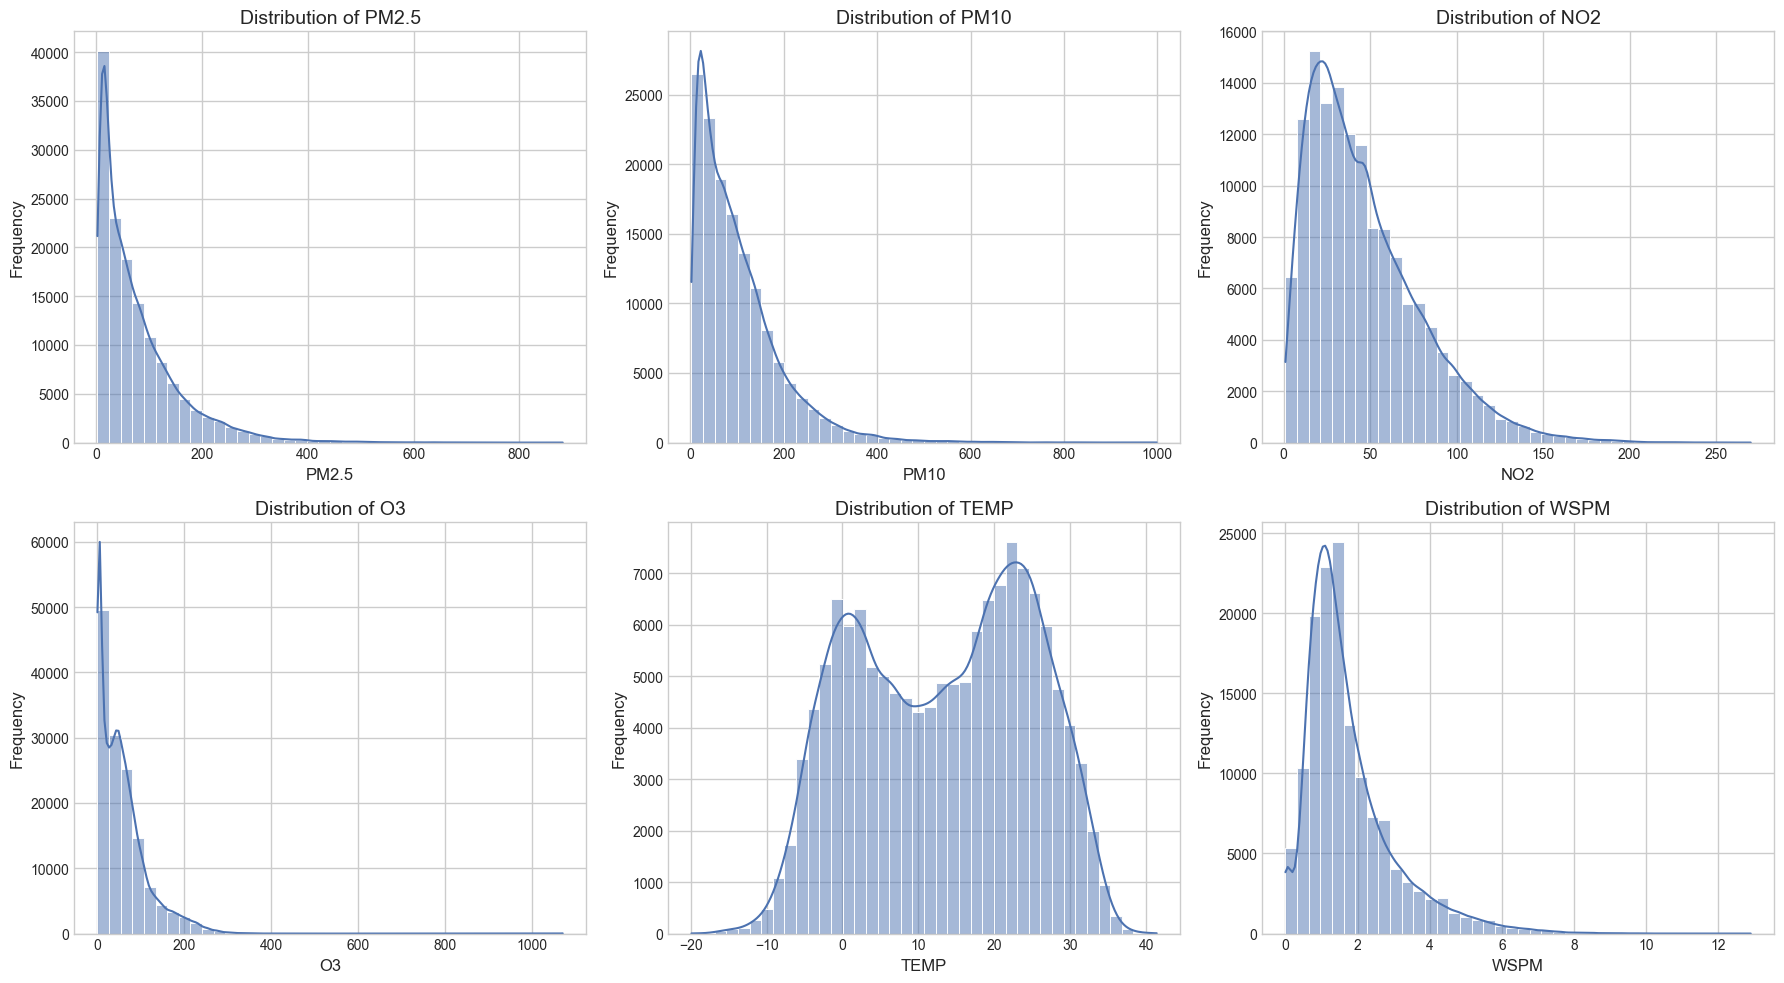

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

vars_to_plot = ["PM2.5", "PM10", "NO2", "O3", "TEMP", "WSPM"]

for ax, col in zip(axes, vars_to_plot):
    sns.histplot(df_clean[col], bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}", fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.show()

### *Box plots by station*

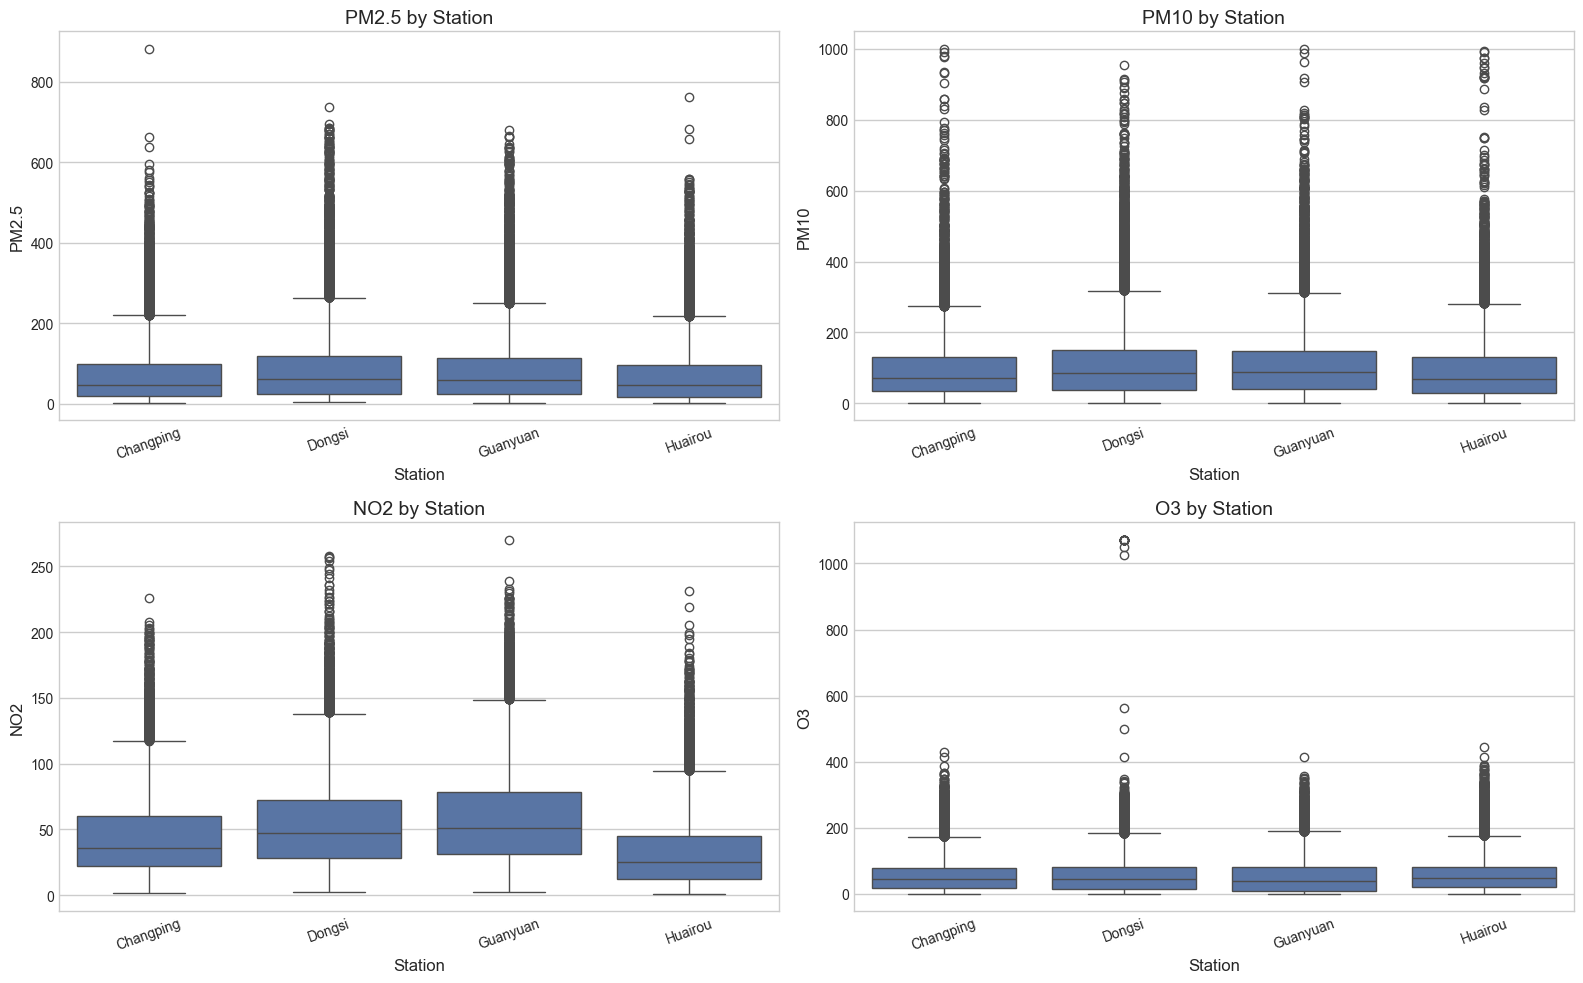

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

vars_to_plot = ["PM2.5", "PM10", "NO2", "O3"]

for ax, col in zip(axes, vars_to_plot):
    sns.boxplot(data=df_clean, x="station", y=col, ax=ax)
    ax.set_title(f"{col} by Station", fontsize=14)
    ax.set_xlabel("Station", fontsize=12)
    ax.set_ylabel(col, fontsize=12)
    ax.tick_params(axis="x", rotation=20, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

plt.tight_layout()
plt.show()

### *Bivariate scatter plots*

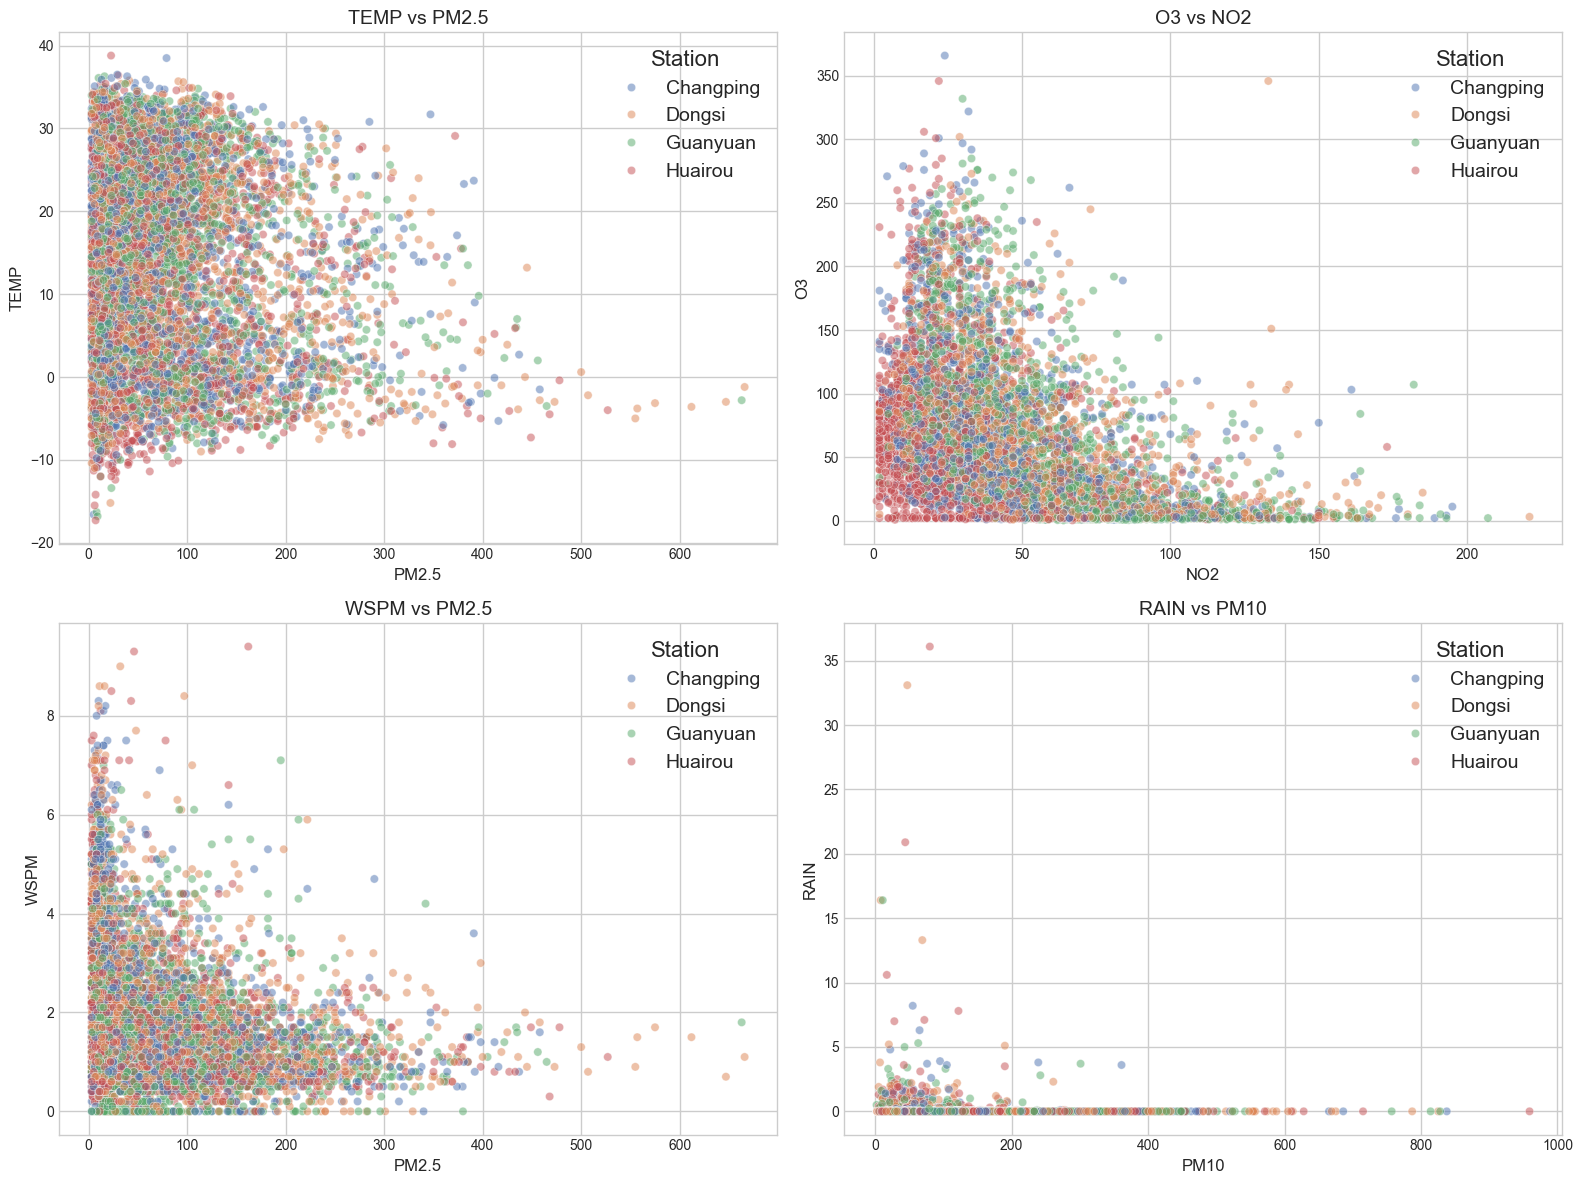

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

pairs = [("PM2.5", "TEMP"), ("NO2", "O3"), ("PM2.5", "WSPM"), ("PM10", "RAIN")]
sampled_df = df_clean.sample(8000, random_state=42)

for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(
        data=sampled_df,
        x=x,
        y=y,
        hue="station",
        alpha=0.5,
        ax=ax,
    )
    ax.set_title(f"{y} vs {x}", fontsize=14)
    ax.set_xlabel(x, fontsize=12)
    ax.set_ylabel(y, fontsize=12)
    ax.tick_params(axis="both", labelsize=10)
    ax.legend(title="Station", title_fontsize=16, fontsize=14, loc="upper right")

plt.tight_layout()
plt.show()

### *Multivariate correlation heatmap*

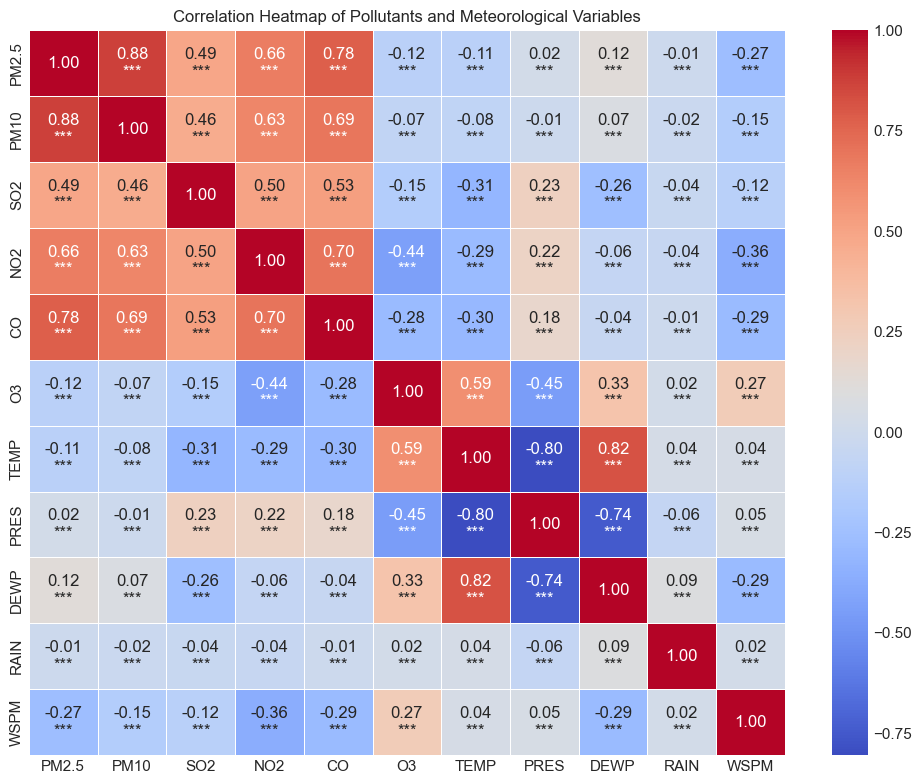

In [39]:
from scipy.stats import pearsonr

def asterisks(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

data = df_clean[key_numeric].dropna()
corr = df_clean[key_numeric].corr()

# p-value matrix
p_val = pd.DataFrame(np.ones((len(corr), len(corr))),
                     index=corr.index, columns=corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if i != j:
            r, p = pearsonr(data.iloc[:, i], data.iloc[:, j])
            p_val.iloc[i, j] = p
        else:
            p_val.iloc[i, j] = np.nan

# annotation matrix as strings
annot = pd.DataFrame("", index=corr.index, columns=corr.columns)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        if i == j:
            annot.iloc[i, j] = f"{corr.iloc[i, j]:.2f}"
        else:
            annot.iloc[i, j] = f"{corr.iloc[i, j]:.2f}\n{asterisks(p_val.iloc[i, j])}"

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=annot, fmt="", cmap="coolwarm", square=False, linewidths=.5)
plt.title("Correlation Heatmap of Pollutants and Meteorological Variables")
plt.tight_layout()
plt.show()

### *Pairplot on a sample*

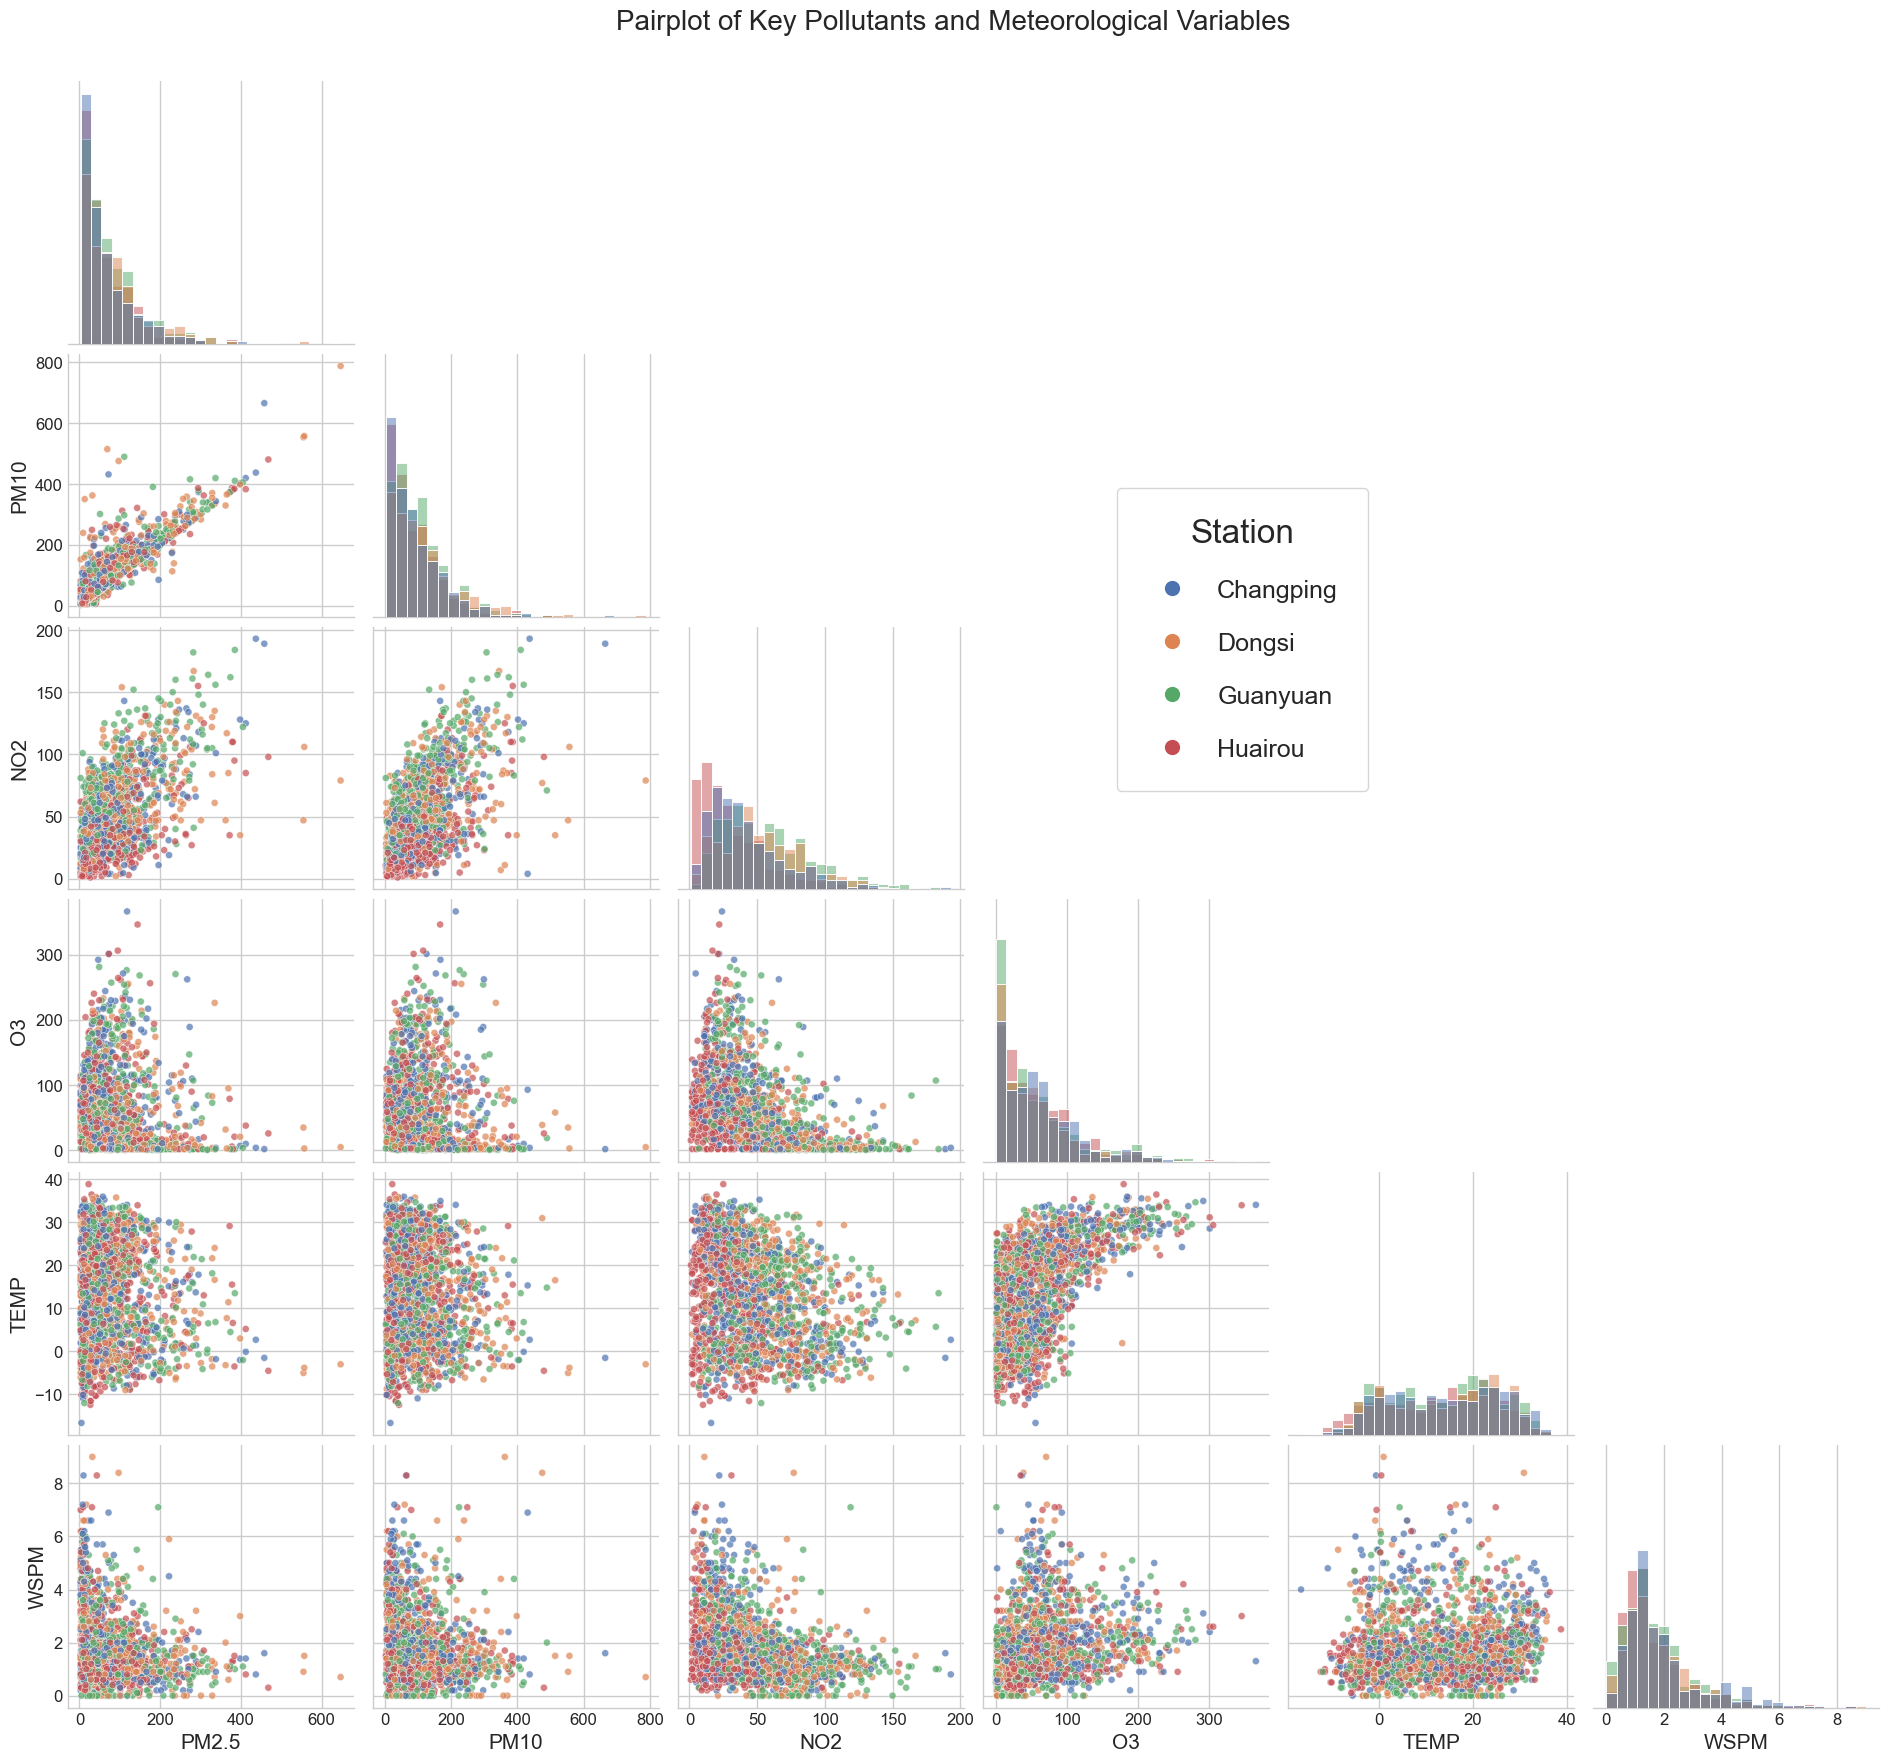

In [46]:
from matplotlib.lines import Line2D

pairplot_vars = ["PM2.5", "PM10", "NO2", "O3", "TEMP", "WSPM"]
sample_df = df_clean[pairplot_vars + ["station"]].sample(2000, random_state=42).copy()

g = sns.pairplot(
    sample_df,
    vars=pairplot_vars,
    hue="station",
    corner=True,
    diag_kind="hist",
    height=3.0,
    plot_kws={"alpha": 0.7, "s": 26},
    diag_kws={"bins": 25},
)

# enlarge axis labels and tick labels
for ax in g.axes.flatten():
    if ax is not None:
        ax.xaxis.label.set_size(15)
        ax.yaxis.label.set_size(15)
        ax.tick_params(axis="both", labelsize=12)

# remove seaborn default legend
if g._legend is not None:
    g._legend.remove()

# station labels as plain list
if hasattr(sample_df["station"], "cat"):
    stations = list(sample_df["station"].cat.categories)
else:
    stations = sorted(sample_df["station"].astype(str).unique().tolist())

palette = sns.color_palette(n_colors=len(stations))

handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=station,
        markerfacecolor=palette[i],
        markersize=12
    )
    for i, station in enumerate(stations)
]

# place legend in blank area
g.figure.legend(
    handles=handles,
    labels=list(stations),
    title="Station",
    title_fontsize=24,
    fontsize=18,
    loc="center",
    bbox_to_anchor=(0.65, 0.63),
    frameon=True,
    borderpad=1.2,
    labelspacing=1.2,
    handletextpad=0.8
)

g.figure.subplots_adjust(top=0.94, right=0.98)
g.figure.suptitle("Pairplot of Key Pollutants and Meteorological Variables", fontsize=20)

plt.show()